# Minimum history and demand evidence

This notebook defines a whole-series cutoff before later exploratory analysis and modelling. It combines source-class coverage with the distributions of history length, observed active days, positive-demand days, and intermittency. A sensitivity surface makes the retention trade-off visible before selecting the rule. The same diagnostics are then repeated after filtering.

A row in the prepared daily data is an observed active/open day for a product-store series. Closed days are not inserted. Therefore `active_days` counts observed rows and `demand_days` counts observed rows with strictly positive kilograms.


In [1]:
from pathlib import Path
from io import BytesIO
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import duckdb
import matplotlib
matplotlib.use("Agg")
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Image, Markdown

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")

GROUP_ORDER = ["FCM", "Pseudo"]
GROUP_COLS = ["ARTIKEL_ID", "MARKT_ID"]
GROUP_COLORS = {"FCM": "#c4513b", "Pseudo": "#d7a84b", "Pooled": "#7d8588"}
MEASURE_LABELS = {
    "calendar_span_days": "Calendar span (days)",
    "active_days": "Observed active days",
    "demand_days": "Positive-demand days",
    "demand_day_ratio": "Demand days / active days",
}

# Source-specific decisions evaluated below. Keep the constants visible.
CUTOFFS = {
    "FCM": {"active_days": 30, "demand_days": 10},
    "Pseudo": {"active_days": 120, "demand_days": 30},
}
ACTIVE_CANDIDATES = {
    "FCM": [5, 7, 10, 14, 15, 21, 30, 45, 60],
    "Pseudo": [10, 14, 15, 21, 30, 45, 60, 90, 120],
}
DEMAND_CANDIDATES = {
    "FCM": [1, 2, 3, 4, 5, 7, 10, 15],
    "Pseudo": [2, 3, 4, 5, 7, 10, 15, 20, 30],
}


PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".."), Path(".")] if (p / "src").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the project root containing src/.")

DATA_DIR = PROJECT_ROOT / "data" / "interim" / "transactions_dst_daily_no_tail"
parquet_files = sorted(DATA_DIR.glob("*.parquet"))
if not parquet_files:
    raise FileNotFoundError(f"No parquet files found in {DATA_DIR}")
DATA_GLOB = str(DATA_DIR / "*.parquet")

con = duckdb.connect()
con.execute("PRAGMA threads=4")

def display_figure(fig, dpi=120):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def five_number_summary(frame, by):
    parts = []
    for measure in MEASURE_LABELS:
        result = (
            frame.groupby(by, observed=True)[measure]
            .agg(
                series="size", minimum="min",
                q25=lambda values: values.quantile(0.25),
                median="median", q75=lambda values: values.quantile(0.75),
                maximum="max",
            )
            .reset_index()
        )
        result["measure"] = measure
        parts.append(result)
    return pd.concat(parts, ignore_index=True)

def summarize_distributions(frame):
    pooled = frame.copy()
    pooled["source_class"] = "Pooled"
    combined = pd.concat([frame, pooled], ignore_index=True)
    combined["source_class"] = pd.Categorical(
        combined["source_class"], [*GROUP_ORDER, "Pooled"], ordered=True
    )
    summary = five_number_summary(combined, ["source_class"])
    summary["measure"] = pd.Categorical(
        summary["measure"], list(MEASURE_LABELS), ordered=True
    )
    return combined, summary.sort_values(["measure", "source_class"])

def plot_distributions(combined, title):
    groups = [*GROUP_ORDER, "Pooled"]
    fig, axes = plt.subplots(len(MEASURE_LABELS), len(groups), figsize=(18, 13), constrained_layout=True)
    for row, (measure, label) in enumerate(MEASURE_LABELS.items()):
        for col, group_name in enumerate(groups):
            ax = axes[row, col]
            values = combined.loc[combined["source_class"] == group_name, measure].dropna()
            if measure == "demand_day_ratio":
                bins = np.linspace(0, 1, 31)
                sns.histplot(values, bins=bins, stat="density", color=GROUP_COLORS[group_name], ax=ax)
                ax.set_xlim(0, 1)
                ax.set_xlabel("Ratio")
            else:
                positive = values[values > 0]
                bins = np.geomspace(positive.min(), positive.max(), 36) if positive.max() > positive.min() else 10
                sns.histplot(values, bins=bins, stat="density", color=GROUP_COLORS[group_name], ax=ax)
                ax.set_xscale("log")
                ax.set_xlabel("Days (log scale)")
            ax.set_title(f"{group_name}: {label}")
            ax.set_ylabel("Density")
    fig.suptitle(title, fontsize=16)
    display_figure(fig)


## 1. Data coverage by source class

FCM takes precedence if a row were ever to carry both source flags. The audit below verifies that the source assignment is unambiguous and that each product-store-date occurs once.


,null_fcm_flags,null_pseudo_flags,overlapping_source_flags,duplicate_series_dates
0,0.0,0.0,0.0,0


,source_class,rows,stores,products,series,first_date,last_date,total_demand_kg
0,FCM,"869,794",195,32,"3,891",2025-04-17 00:00:00,2026-07-21 00:00:00,"156,086.4"
1,Pseudo,"23,779,094",194,457,"30,573",2023-07-22 00:00:00,2026-07-21 00:00:00,"20,478,124.4"


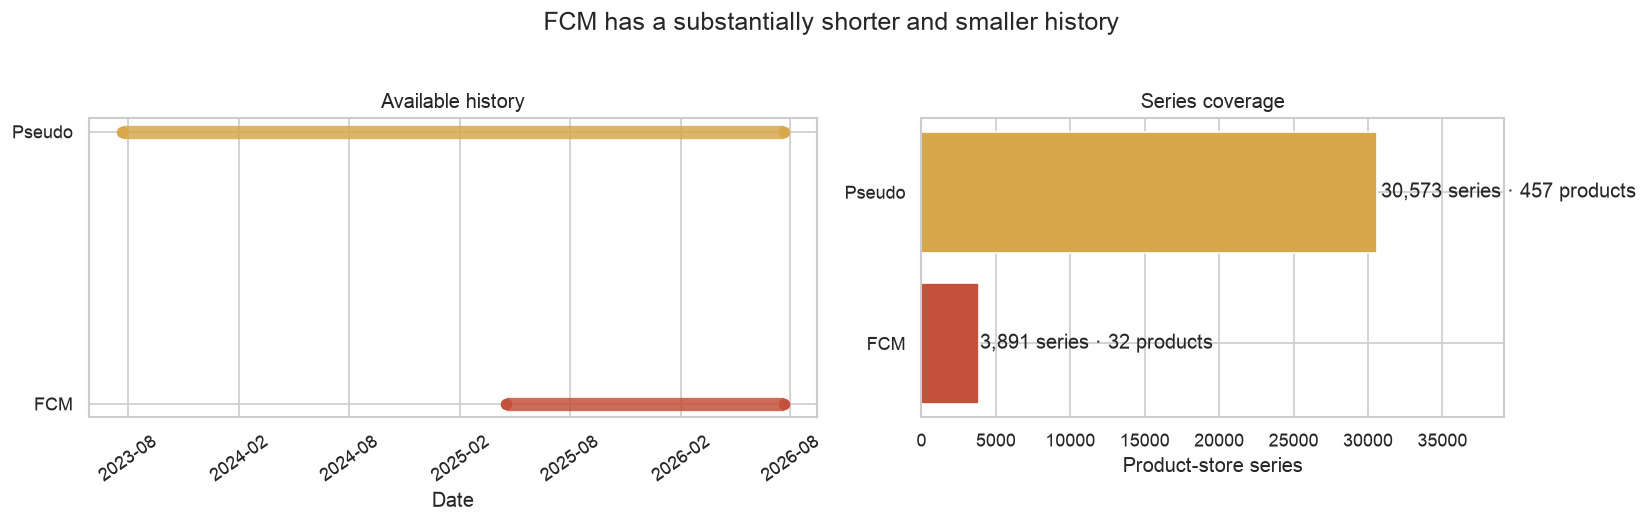

In [2]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW daily_rows AS
SELECT
    ARTIKEL_ID, MARKT_ID, CAST(DATE AS DATE) AS period,
    CAST(COALESCE(ABVERKAUFTE_MENGE_KG, 0) AS DOUBLE) AS demand,
    WGR_ID::INTEGER AS category_id,
    is_fcm, is_pseudo,
    CASE WHEN is_fcm THEN 'FCM' WHEN is_pseudo THEN 'Pseudo' END AS source_class
FROM read_parquet('{DATA_GLOB}')
WHERE is_fcm OR is_pseudo
""")

audit = con.execute("""
SELECT
    COUNT_IF(is_fcm IS NULL) AS null_fcm_flags,
    COUNT_IF(is_pseudo IS NULL) AS null_pseudo_flags,
    COUNT_IF(is_fcm AND is_pseudo) AS overlapping_source_flags,
    (SELECT COUNT(*) FROM (
        SELECT ARTIKEL_ID, MARKT_ID, period FROM daily_rows
        GROUP BY ALL HAVING COUNT(*) > 1
    )) AS duplicate_series_dates
FROM daily_rows
""").fetchdf()
display(audit)
if audit.sum(axis=1).iloc[0] != 0:
    raise RuntimeError("Source or uniqueness audit failed; inspect the audit table.")

coverage = con.execute("""
SELECT
    source_class, COUNT(*) AS rows,
    COUNT(DISTINCT MARKT_ID) AS stores,
    COUNT(DISTINCT ARTIKEL_ID) AS products,
    COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series,
    MIN(period) AS first_date, MAX(period) AS last_date,
    SUM(demand) AS total_demand_kg
FROM daily_rows
GROUP BY source_class
ORDER BY CASE source_class WHEN 'FCM' THEN 1 ELSE 2 END
""").fetchdf()
display(coverage.style.format({
    "rows": "{:,.0f}", "stores": "{:,.0f}", "products": "{:,.0f}",
    "series": "{:,.0f}", "total_demand_kg": "{:,.1f}",
}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.25, 1]})
for y, row in coverage.reset_index(drop=True).iterrows():
    color = GROUP_COLORS[row.source_class]
    axes[0].hlines(y, row.first_date, row.last_date, color=color, linewidth=8, alpha=0.85)
    axes[0].scatter([row.first_date, row.last_date], [y, y], color=color, s=35, zorder=3)
axes[0].set_yticks(range(len(coverage)), coverage.source_class)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0].tick_params(axis="x", rotation=35)
axes[0].set(title="Available history", xlabel="Date")
bars = axes[1].barh(coverage.source_class, coverage.series, color=[GROUP_COLORS[x] for x in coverage.source_class])
for bar, series, products in zip(bars, coverage.series, coverage.products):
    axes[1].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
                 f"{series:,} series · {products:,} products", va="center")
axes[1].set_xlim(0, coverage.series.max() * 1.28)
axes[1].set(title="Series coverage", xlabel="Product-store series")
fig.suptitle("FCM has a substantially shorter and smaller history", fontsize=15, y=1.03)
fig.tight_layout()
display_figure(fig)


## 2. Before filtering: history length, demand evidence, and intermittency

For every product-store series:

1. `calendar_span_days` is the inclusive distance from first to last observed date.
2. `active_days` counts observed active/open days.
3. `demand_days` counts active days with strictly positive demand.
4. `demand_day_ratio` is a compact intermittency measure; lower values mean more zero-demand active days.


,source_class,series,minimum,q25,median,q75,maximum,measure
0,FCM,"3,891",2,173,310,407,461,calendar_span_days
1,Pseudo,"30,573",2,949,1.08e+03,1.1e+03,1.1e+03,calendar_span_days
2,Pooled,"34,464",2,713,1.07e+03,1.09e+03,1.1e+03,calendar_span_days
3,FCM,"3,891",2,143,256,339,434,active_days
4,Pseudo,"30,573",2,785,897,909,1.07e+03,active_days
5,Pooled,"34,464",2,591,888,909,1.07e+03,active_days
6,FCM,"3,891",1,11,53,122,368,demand_days
7,Pseudo,"30,573",1,26,99,286,983,demand_days
8,Pooled,"34,464",1,23,89,259,983,demand_days
9,FCM,"3,891",0.00578,0.133,0.296,0.522,1,demand_day_ratio


Lower-tail evidence used to choose source-specific cutoffs:


,source_class,quantile,active_days,demand_days
0,FCM,1%,6.0,1.0
1,FCM,2%,10.0,1.0
2,FCM,3%,12.0,2.0
3,FCM,4%,14.0,2.0
4,FCM,5%,15.0,3.0
5,FCM,10%,27.0,5.0
6,FCM,15%,32.0,6.0
7,FCM,20%,82.0,8.0
8,FCM,25%,143.0,11.0
9,Pseudo,1%,17.0,1.0


Lower-tail evidence used to choose source-specific cutoffs:


,source_class,quantile,active_days,demand_days
0,FCM,1%,6.0,1.0
1,FCM,2%,10.0,1.0
2,FCM,3%,12.0,2.0
3,FCM,4%,14.0,2.0
4,FCM,5%,15.0,3.0
5,FCM,10%,27.0,5.0
6,FCM,15%,32.0,6.0
7,FCM,20%,82.0,8.0
8,FCM,25%,143.0,11.0
9,Pseudo,1%,17.0,1.0


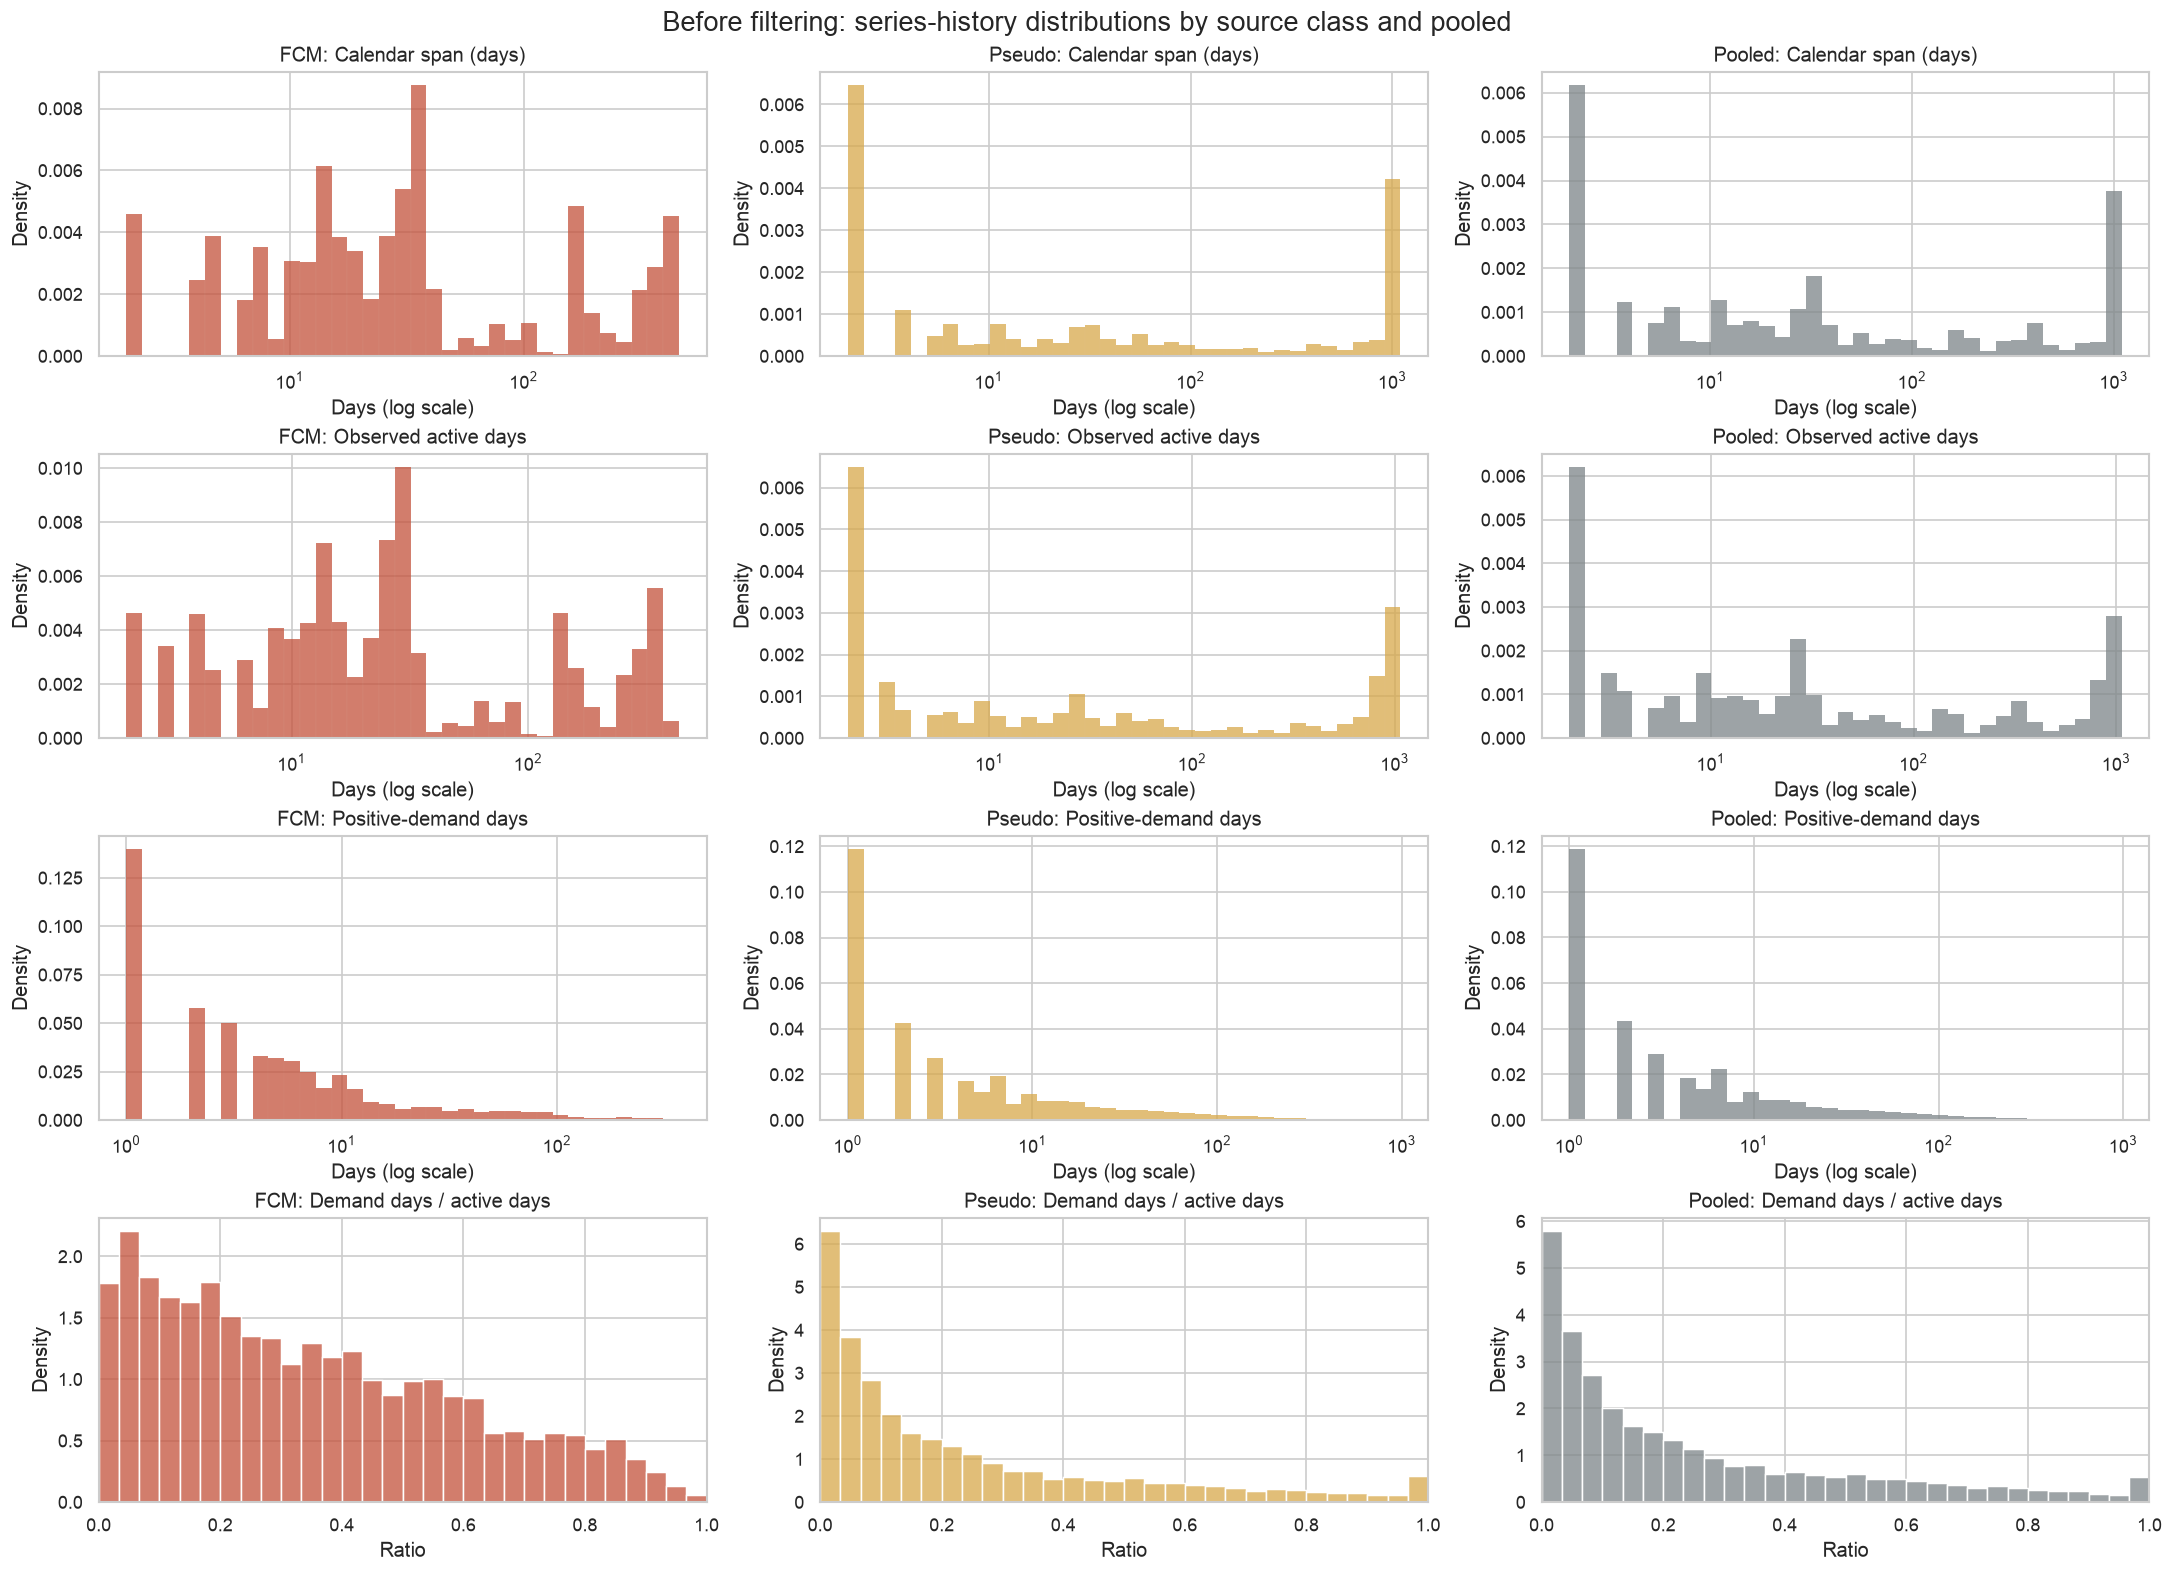

In [3]:
series_distribution = con.execute("""
SELECT
    source_class, category_id, ARTIKEL_ID, MARKT_ID,
    MIN(period) AS first_period, MAX(period) AS last_period,
    DATE_DIFF('day', MIN(period), MAX(period)) + 1 AS calendar_span_days,
    COUNT(*) AS active_days,
    COUNT_IF(demand > 0) AS demand_days,
    COUNT_IF(demand > 0)::DOUBLE / COUNT(*) AS demand_day_ratio,
    SUM(demand) AS total_demand_kg
FROM daily_rows
GROUP BY source_class, category_id, ARTIKEL_ID, MARKT_ID
""").fetchdf()
series_distribution["source_class"] = pd.Categorical(
    series_distribution["source_class"], GROUP_ORDER, ordered=True
)

before_combined, before_summary = summarize_distributions(series_distribution)
display(before_summary.style.format({
    "series": "{:,.0f}", "minimum": "{:,.3g}", "q25": "{:,.3g}",
    "median": "{:,.3g}", "q75": "{:,.3g}", "maximum": "{:,.3g}",
}))
lower_tail_rows = []
for group_name in GROUP_ORDER:
    group = series_distribution[series_distribution.source_class == group_name]
    for quantile in [0.01, 0.02, 0.03, 0.04, 0.05, 0.10, 0.15, 0.20, 0.25]:
        lower_tail_rows.append({
            "source_class": group_name,
            "quantile": quantile,
            "active_days": group.active_days.quantile(quantile),
            "demand_days": group.demand_days.quantile(quantile),
        })
lower_tail_quantiles = pd.DataFrame(lower_tail_rows)
print("Lower-tail evidence used to choose source-specific cutoffs:")
display(lower_tail_quantiles.style.format({
    "quantile": "{:.0%}", "active_days": "{:,.1f}", "demand_days": "{:,.1f}",
}))

lower_tail_rows = []
for group_name in GROUP_ORDER:
    group = series_distribution[series_distribution.source_class == group_name]
    for quantile in [0.01, 0.02, 0.03, 0.04, 0.05, 0.10, 0.15, 0.20, 0.25]:
        lower_tail_rows.append({
            "source_class": group_name,
            "quantile": quantile,
            "active_days": group.active_days.quantile(quantile),
            "demand_days": group.demand_days.quantile(quantile),
        })
lower_tail_quantiles = pd.DataFrame(lower_tail_rows)
print("Lower-tail evidence used to choose source-specific cutoffs:")
display(lower_tail_quantiles.style.format({
    "quantile": "{:.0%}", "active_days": "{:,.1f}", "demand_days": "{:,.1f}",
}))

plot_distributions(
    before_combined,
    "Before filtering: series-history distributions by source class and pooled",
)


## 3. Source-specific threshold sensitivity and decision

The source classes should not share a cutoff because their available histories and demand evidence differ substantially. The rule is selected from the sensitivity surface after the no-tail step and before outlier cleaning. The selected rules prioritize a stronger minimum evidence base; retained demand volume remains visible in the audit tables but is not used as a heatmap matrix.

FCM starts later, so its evidence floor remains lower. Pseudo has much longer available histories and can support a stricter rule:

$$
\begin{aligned}
\text{FCM:}&\quad \text{active days} \ge 30,\quad \text{demand days} \ge 10,\\
\text{Pseudo:}&\quad \text{active days} \ge 120,\quad \text{demand days} \ge 30.
\end{aligned}
$$

These are whole-series data-quality cutoffs. Forecast-origin eligibility may still impose stricter training requirements later.


Selected source-specific rules:


,source_class,min_active_days,min_demand_days,series_retained,demand_kg_retained
0,FCM,30,10,74.71%,97.733%
1,Pseudo,120,30,72.82%,99.547%


Selected rules versus nearby alternatives:


,source_class,min_active_days,min_demand_days,series_retained,demand_kg_retained,role
0,FCM,21,5,88.10%,99.497%,alternative
1,FCM,30,10,74.71%,97.733%,selected
2,FCM,45,10,73.76%,97.592%,alternative
3,Pseudo,60,15,81.92%,99.845%,alternative
4,Pseudo,90,20,78.45%,99.759%,alternative
5,Pseudo,120,30,72.82%,99.547%,selected


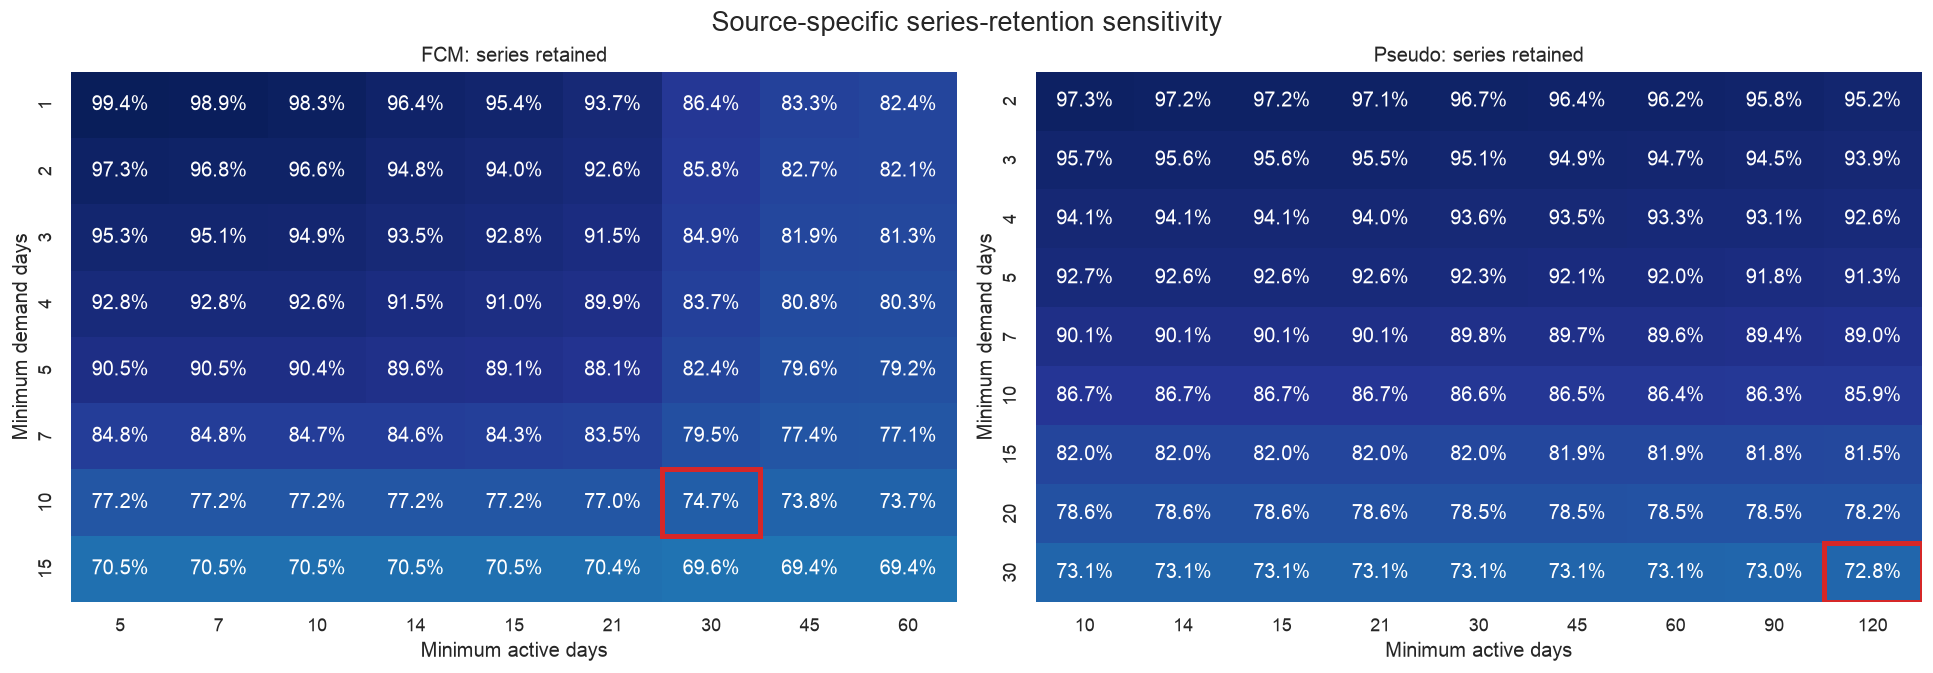

**Selected source-specific cutoffs:** FCM ≥30 active / ≥10 demand days retains 74.71% of series and 97.733% of demand. Pseudo ≥120 active / ≥30 demand days retains 72.82% of series and 99.547% of demand. The stricter Pseudo rule reflects its substantially longer available history.

In [4]:
surface_rows = []
for group_name in GROUP_ORDER:
    group = series_distribution[series_distribution.source_class == group_name]
    for active_cutoff in ACTIVE_CANDIDATES[group_name]:
        for demand_cutoff in DEMAND_CANDIDATES[group_name]:
            keep = (group.active_days >= active_cutoff) & (group.demand_days >= demand_cutoff)
            surface_rows.append({
                "source_class": group_name,
                "min_active_days": active_cutoff,
                "min_demand_days": demand_cutoff,
                "series_retained": keep.mean(),
                "demand_kg_retained": (
                    group.loc[keep, "total_demand_kg"].sum() / group.total_demand_kg.sum()
                ),
            })
threshold_surface = pd.DataFrame(surface_rows)

selected_rows = []
for group_name, cutoff in CUTOFFS.items():
    selected_rows.append(
        threshold_surface[
            (threshold_surface.source_class == group_name)
            & (threshold_surface.min_active_days == cutoff["active_days"])
            & (threshold_surface.min_demand_days == cutoff["demand_days"])
        ].iloc[0]
    )
selected_retention = pd.DataFrame(selected_rows).reset_index(drop=True)
print("Selected source-specific rules:")
display(selected_retention.style.format({
    "series_retained": "{:.2%}", "demand_kg_retained": "{:.3%}",
}))

comparison_specs = {
    "FCM": [(21, 5), (30, 10), (45, 10)],
    "Pseudo": [(60, 15), (90, 20), (120, 30)],
}
comparison_rows = []
for group_name, pairs in comparison_specs.items():
    for active_cutoff, demand_cutoff in pairs:
        row = threshold_surface[
            (threshold_surface.source_class == group_name)
            & (threshold_surface.min_active_days == active_cutoff)
            & (threshold_surface.min_demand_days == demand_cutoff)
        ].iloc[0].to_dict()
        row["role"] = (
            "selected" if active_cutoff == CUTOFFS[group_name]["active_days"]
            and demand_cutoff == CUTOFFS[group_name]["demand_days"]
            else "alternative"
        )
        comparison_rows.append(row)
decision_comparison = pd.DataFrame(comparison_rows)
print("Selected rules versus nearby alternatives:")
display(decision_comparison.style.format({
    "series_retained": "{:.2%}", "demand_kg_retained": "{:.3%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)
for ax, group_name in zip(axes, GROUP_ORDER):
    group_surface = threshold_surface[threshold_surface.source_class == group_name]
    cutoff = CUTOFFS[group_name]
    matrix = group_surface.pivot(
        index="min_demand_days", columns="min_active_days", values="series_retained"
    )
    sns.heatmap(
        matrix, annot=True, fmt=".1%", cmap="YlGnBu", vmin=0, vmax=1,
        cbar=False, ax=ax,
    )
    selected_col = list(matrix.columns).index(cutoff["active_days"])
    selected_row = list(matrix.index).index(cutoff["demand_days"])
    ax.add_patch(plt.Rectangle(
        (selected_col, selected_row), 1, 1,
        fill=False, edgecolor="#d62728", linewidth=3,
    ))
    ax.set(
        title=f"{group_name}: series retained",
        xlabel="Minimum active days", ylabel="Minimum demand days",
    )
fig.suptitle("Source-specific series-retention sensitivity", fontsize=16)
display_figure(fig)

fcm = selected_retention[selected_retention.source_class == "FCM"].iloc[0]
pseudo = selected_retention[selected_retention.source_class == "Pseudo"].iloc[0]
display(Markdown(
    f"**Selected source-specific cutoffs:** FCM ≥30 active / ≥10 demand days "
    f"retains {fcm.series_retained:.2%} of series and {fcm.demand_kg_retained:.3%} "
    f"of demand. Pseudo ≥120 active / ≥30 demand days retains "
    f"{pseudo.series_retained:.2%} of series and {pseudo.demand_kg_retained:.3%} "
    "of demand. The stricter Pseudo rule reflects its substantially longer available history."
))


## 4. Apply the source-specific cutoffs

Each rule is applied at product-store level within its source class. Every row belonging to an ineligible series is excluded; no individual dates are selected or imputed.


In [5]:
keep_mask = pd.Series(False, index=series_distribution.index)
for group_name, cutoff in CUTOFFS.items():
    keep_mask |= (
        (series_distribution.source_class == group_name)
        & (series_distribution.active_days >= cutoff["active_days"])
        & (series_distribution.demand_days >= cutoff["demand_days"])
    )

eligible_series = series_distribution.loc[keep_mask, GROUP_COLS].copy()
con.register("eligible_series", eligible_series)
con.execute("""
CREATE OR REPLACE TEMP VIEW filtered_daily_rows AS
SELECT d.*
FROM daily_rows d
INNER JOIN eligible_series e USING (ARTIKEL_ID, MARKT_ID)
""")

filter_effect = con.execute("""
WITH before AS (
    SELECT source_class, COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series_before,
           COUNT(*) AS rows_before, SUM(demand) AS kg_before
    FROM daily_rows GROUP BY source_class
), after AS (
    SELECT source_class, COUNT(DISTINCT (ARTIKEL_ID, MARKT_ID)) AS series_after,
           COUNT(*) AS rows_after, SUM(demand) AS kg_after
    FROM filtered_daily_rows GROUP BY source_class
)
SELECT *, series_after::DOUBLE / series_before AS series_retained,
          rows_after::DOUBLE / rows_before AS rows_retained,
          kg_after / kg_before AS demand_kg_retained
FROM before JOIN after USING (source_class)
ORDER BY CASE source_class WHEN 'FCM' THEN 1 ELSE 2 END
""").fetchdf()
display(filter_effect.style.format({
    "series_before": "{:,.0f}", "series_after": "{:,.0f}",
    "rows_before": "{:,.0f}", "rows_after": "{:,.0f}",
    "kg_before": "{:,.1f}", "kg_after": "{:,.1f}",
    "series_retained": "{:.2%}", "rows_retained": "{:.2%}",
    "demand_kg_retained": "{:.3%}",
}))


,source_class,series_before,rows_before,kg_before,series_after,rows_after,kg_after,series_retained,rows_retained,demand_kg_retained
0,FCM,"3,891","869,794","156,086.4","2,907","790,764","152,548.6",74.71%,90.91%,97.733%
1,Pseudo,"30,573","23,779,094","20,478,124.4","22,262","19,144,123","20,385,310.7",72.82%,80.51%,99.547%


## 5. After filtering: history length, demand evidence, and intermittency

The same metrics, summary layout, and histogram scales are repeated on the retained population so the effect of the cutoff is directly auditable.


,source_class,series,minimum,q25,median,q75,maximum,measure
0,FCM,"2,907",33,212,365,410,461,calendar_span_days
1,Pseudo,"22,262",148,1.07e+03,1.09e+03,1.1e+03,1.1e+03,calendar_span_days
2,Pooled,"25,169",33,1.03e+03,1.09e+03,1.1e+03,1.1e+03,calendar_span_days
3,FCM,"2,907",30,174,303,340,434,active_days
4,Pseudo,"22,262",122,884,906,909,1.07e+03,active_days
5,Pooled,"25,169",30,851,903,909,1.07e+03,active_days
6,FCM,"2,907",10,39,82,168,368,demand_days
7,Pseudo,"22,262",30,80,180,398,983,demand_days
8,Pooled,"25,169",10,73,164,356,983,demand_days
9,FCM,"2,907",0.0304,0.173,0.359,0.573,0.986,demand_day_ratio


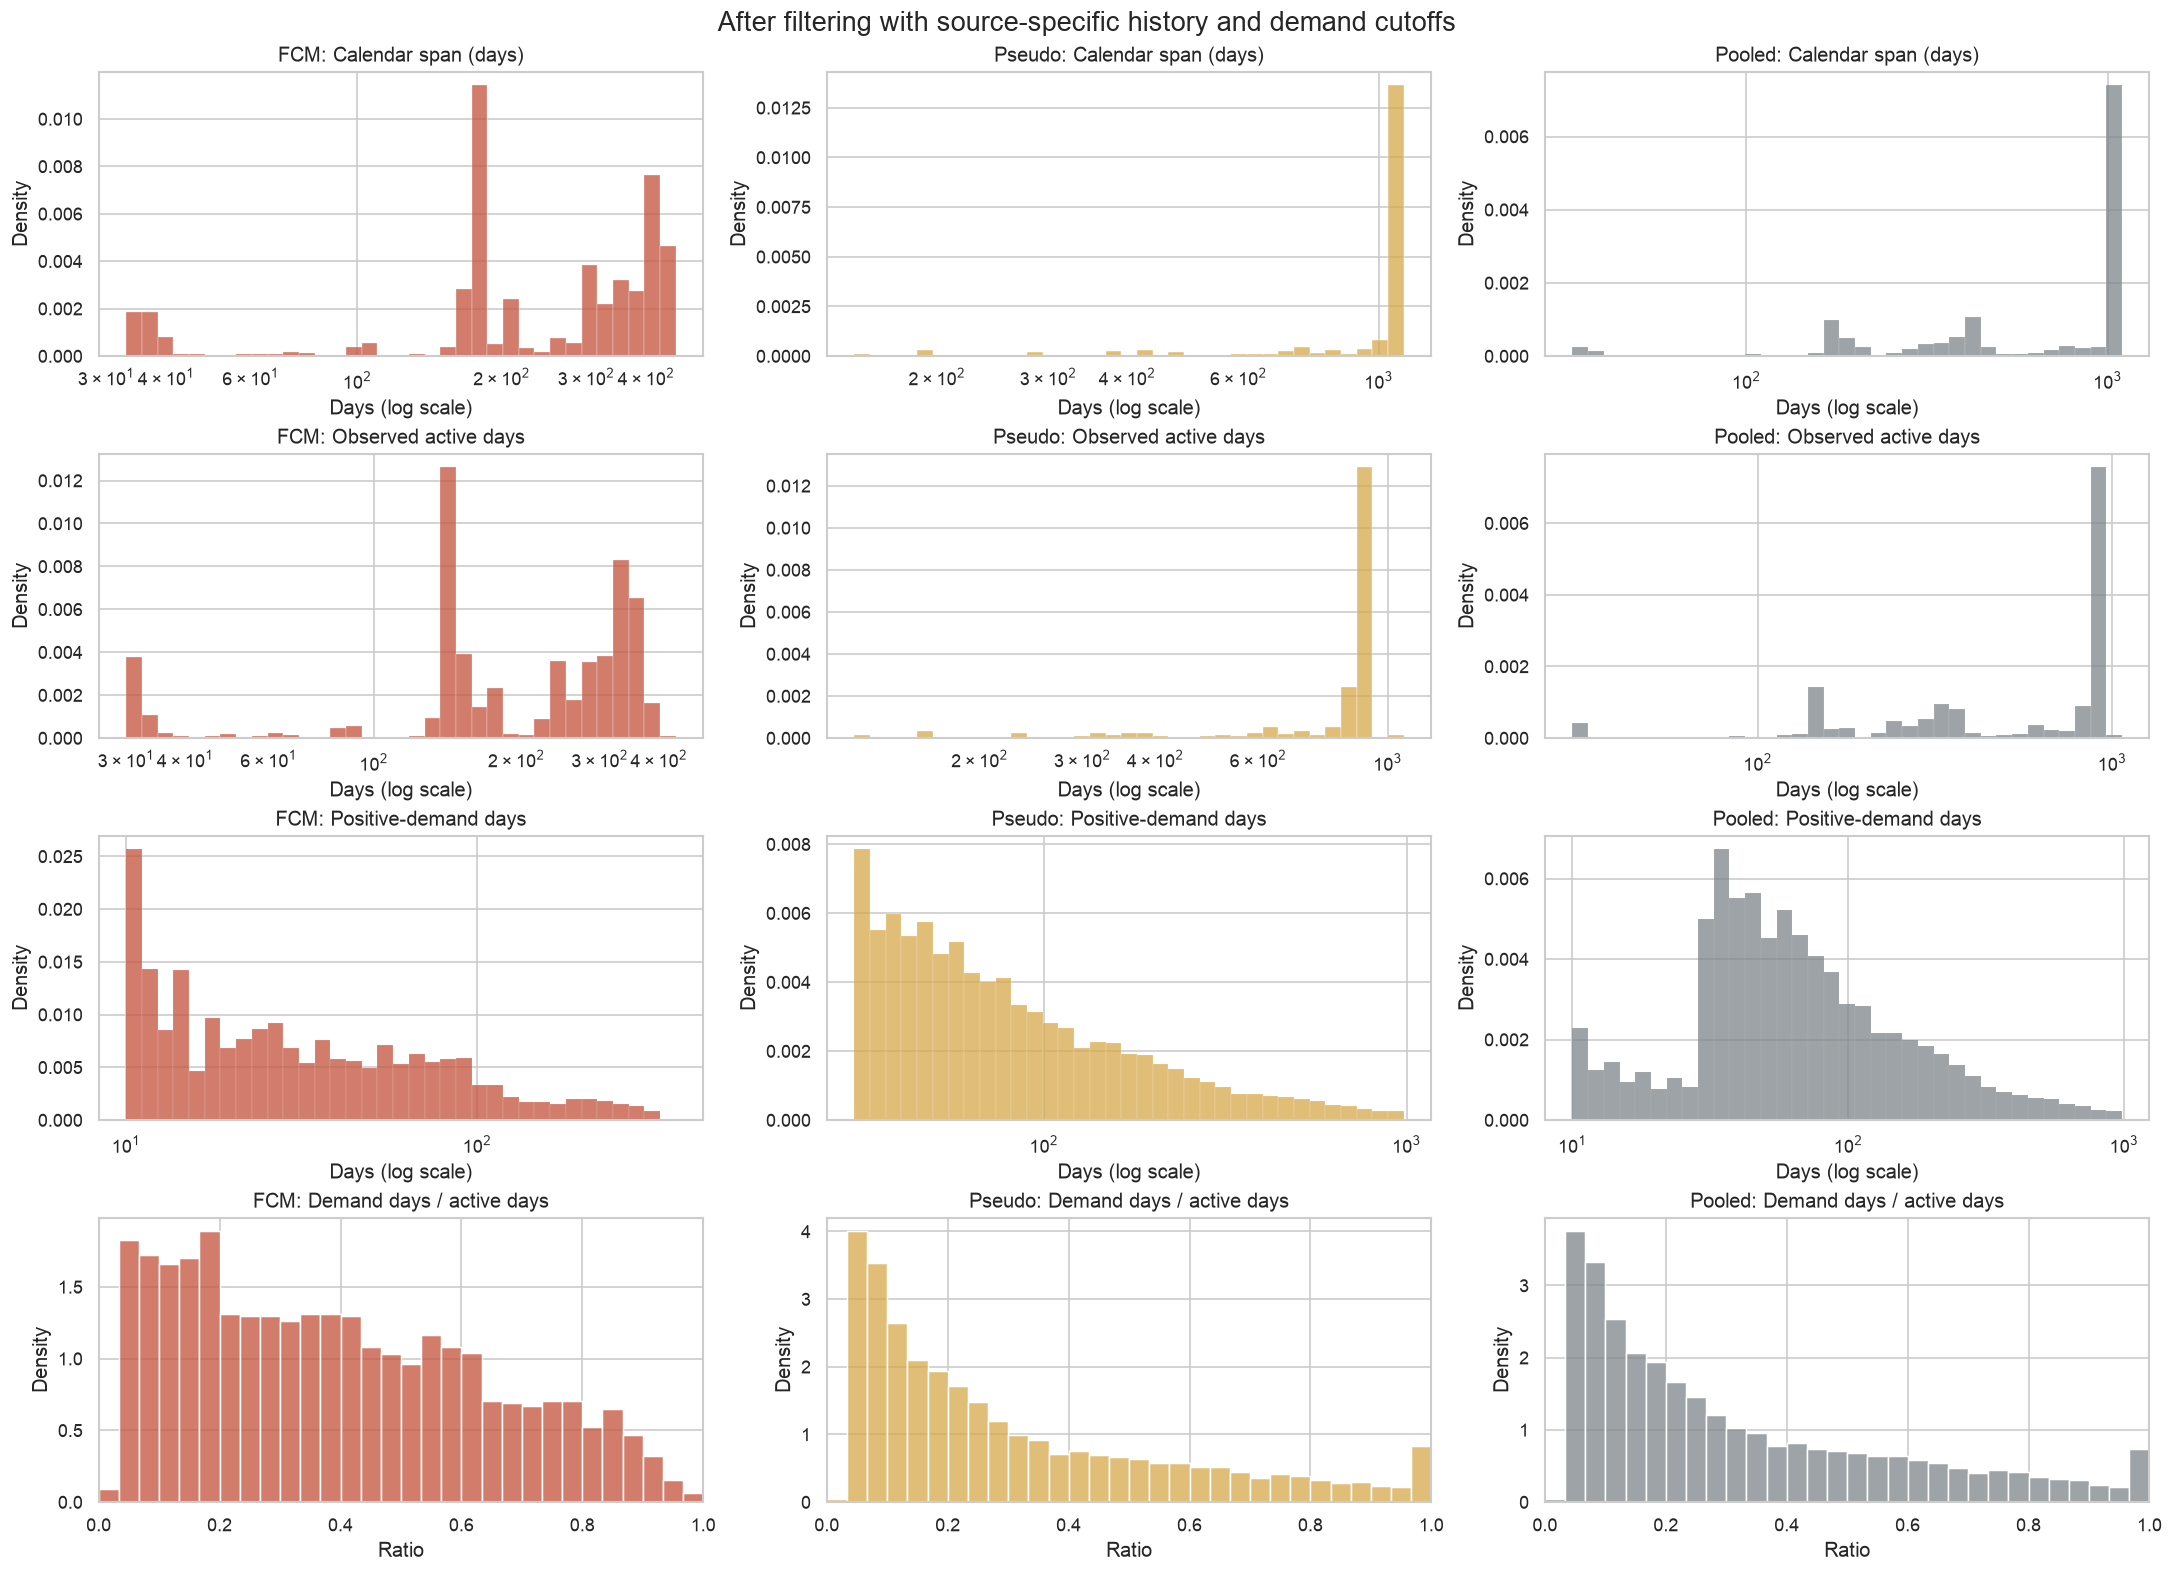

Median series characteristics before and after filtering:


,,calendar_span_days,active_days,demand_days,demand_day_ratio
source_class,stage,,,,
FCM,Before,310.0,256.0,53.0,29.6%
Pseudo,Before,"1,082.0",897.0,99.0,13.3%
FCM,After,365.0,303.0,82.0,35.9%
Pseudo,After,"1,091.0",906.0,180.0,21.4%


In [6]:
filtered_series_distribution = con.execute("""
SELECT
    source_class, category_id, ARTIKEL_ID, MARKT_ID,
    MIN(period) AS first_period, MAX(period) AS last_period,
    DATE_DIFF('day', MIN(period), MAX(period)) + 1 AS calendar_span_days,
    COUNT(*) AS active_days,
    COUNT_IF(demand > 0) AS demand_days,
    COUNT_IF(demand > 0)::DOUBLE / COUNT(*) AS demand_day_ratio,
    SUM(demand) AS total_demand_kg
FROM filtered_daily_rows
GROUP BY source_class, category_id, ARTIKEL_ID, MARKT_ID
""").fetchdf()
filtered_series_distribution["source_class"] = pd.Categorical(
    filtered_series_distribution["source_class"], GROUP_ORDER, ordered=True
)

after_combined, after_summary = summarize_distributions(filtered_series_distribution)
display(after_summary.style.format({
    "series": "{:,.0f}", "minimum": "{:,.3g}", "q25": "{:,.3g}",
    "median": "{:,.3g}", "q75": "{:,.3g}", "maximum": "{:,.3g}",
}))
plot_distributions(
    after_combined,
    "After filtering with source-specific history and demand cutoffs",
)

before_medians = (series_distribution.groupby("source_class", observed=True)
                  [list(MEASURE_LABELS)].median().assign(stage="Before"))
after_medians = (filtered_series_distribution.groupby("source_class", observed=True)
                 [list(MEASURE_LABELS)].median().assign(stage="After"))
median_comparison = (pd.concat([before_medians, after_medians]).reset_index()
                     .set_index(["source_class", "stage"]))
print("Median series characteristics before and after filtering:")
display(median_comparison.style.format({
    "calendar_span_days": "{:,.1f}", "active_days": "{:,.1f}",
    "demand_days": "{:,.1f}", "demand_day_ratio": "{:.1%}",
}))

for group_name, cutoff in CUTOFFS.items():
    retained_group = filtered_series_distribution[
        filtered_series_distribution.source_class == group_name
    ]
    assert retained_group.active_days.min() >= cutoff["active_days"]
    assert retained_group.demand_days.min() >= cutoff["demand_days"]


## Conclusion

The selected source-specific rules require at least 30 active and 10 demand days for FCM, and at least 120 active and 30 demand days for Pseudo. Demand-volume retention remains reported as an audit statistic, while the sensitivity visualization focuses only on the share of series retained. The post-filter distributions verify both rules without altering dates or values inside retained series.
